In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '8000',
        '--feature_ndim', '4',
        '--target_ndim', '2',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '128',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

In [3]:
model = kind.model(args)
dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample))


In [4]:
model.train()
model.fit(dataset)

>>> train nominal mean >>>
	epoch 1 losses: train=0.251176, valid=0.237946, test=0.238094
	validation loss decreased (inf -> 0.237946), saving model ...
	epoch 2 losses: train=0.122513, valid=0.008216, test=0.008046
	validation loss decreased (0.237946 -> 0.008216), saving model ...
	epoch 3 losses: train=0.003069, valid=0.001435, test=0.001430
	validation loss decreased (0.008216 -> 0.001435), saving model ...
	epoch 4 losses: train=0.001014, valid=0.000714, test=0.000712
	validation loss decreased (0.001435 -> 0.000714), saving model ...
	epoch 5 losses: train=0.000571, valid=0.000445, test=0.000448
	validation loss decreased (0.000714 -> 0.000445), saving model ...
	epoch 6 losses: train=0.000347, valid=0.000293, test=0.000293
	validation loss decreased (0.000445 -> 0.000293), saving model ...
	epoch 7 losses: train=0.000255, valid=0.000234, test=0.000233
	validation loss decreased (0.000293 -> 0.000234), saving model ...
	epoch 8 losses: train=0.000212, valid=0.000201, test=0.00020

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

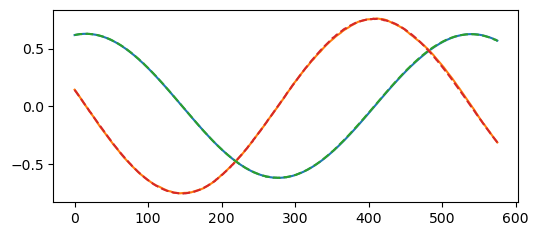

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [7]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train nominal uncertainty >>>
	epoch 1 losses: train=0.043851, valid=0.036308, test=0.036305
	validation loss decreased (inf -> 0.036308), saving model ...
	epoch 2 losses: train=0.035233, valid=0.024101, test=0.024104
	validation loss decreased (0.036308 -> 0.024101), saving model ...
	epoch 3 losses: train=0.020127, valid=0.019291, test=0.019220
	validation loss decreased (0.024101 -> 0.019291), saving model ...
	epoch 4 losses: train=0.018515, valid=0.017147, test=0.017084
	validation loss decreased (0.019291 -> 0.017147), saving model ...
	epoch 5 losses: train=0.016467, valid=0.016387, test=0.016371
	validation loss decreased (0.017147 -> 0.016387), saving model ...
	epoch 6 losses: train=0.016040, valid=0.015880, test=0.015879
	validation loss decreased (0.016387 -> 0.015880), saving model ...
	epoch 7 losses: train=0.015569, valid=0.015258, test=0.015318
	validation loss decreased (0.015880 -> 0.015258), saving model ...
	epoch 8 losses: train=0.014532, valid=0.012365, test=

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

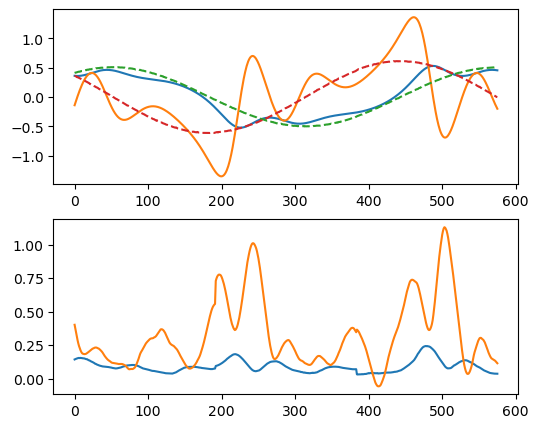

In [9]:
jdata = 7

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]
        stat_u = model_output[2]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(stat_u[0, :, :2])

        plt.show()

        break

In [10]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train excursion mean >>>
	epoch 1 losses: train=0.252023, valid=0.174181, test=0.173361
	validation loss decreased (inf -> 0.174181), saving model ...
	epoch 2 losses: train=0.113045, valid=0.093413, test=0.093052
	validation loss decreased (0.174181 -> 0.093413), saving model ...
	epoch 3 losses: train=0.085631, valid=0.069291, test=0.069306
	validation loss decreased (0.093413 -> 0.069291), saving model ...
	epoch 4 losses: train=0.053780, valid=0.040180, test=0.040246
	validation loss decreased (0.069291 -> 0.040180), saving model ...
	epoch 5 losses: train=0.033143, valid=0.020927, test=0.021391
	validation loss decreased (0.040180 -> 0.020927), saving model ...
	epoch 6 losses: train=0.016482, valid=0.010428, test=0.010619
	validation loss decreased (0.020927 -> 0.010428), saving model ...
	epoch 7 losses: train=0.008936, valid=0.006008, test=0.006108
	validation loss decreased (0.010428 -> 0.006008), saving model ...
	epoch 8 losses: train=0.004934, valid=0.002552, test=0.002

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

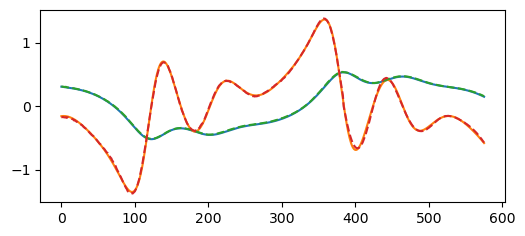

In [12]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[3]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [13]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train excursion uncertainty >>>
	epoch 1 losses: train=0.048609, valid=0.033691, test=0.033635
	validation loss decreased (inf -> 0.033691), saving model ...
	epoch 2 losses: train=0.025716, valid=0.018354, test=0.018463
	validation loss decreased (0.033691 -> 0.018354), saving model ...
	epoch 3 losses: train=0.017735, valid=0.017184, test=0.017207
	validation loss decreased (0.018354 -> 0.017184), saving model ...
	epoch 4 losses: train=0.015962, valid=0.015224, test=0.015159
	validation loss decreased (0.017184 -> 0.015224), saving model ...
	epoch 5 losses: train=0.015141, valid=0.014885, test=0.014833
	validation loss decreased (0.015224 -> 0.014885), saving model ...
	epoch 6 losses: train=0.014805, valid=0.014460, test=0.014395
	validation loss decreased (0.014885 -> 0.014460), saving model ...
	epoch 7 losses: train=0.014129, valid=0.012778, test=0.012769
	validation loss decreased (0.014460 -> 0.012778), saving model ...
	epoch 8 losses: train=0.012044, valid=0.011102, tes

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

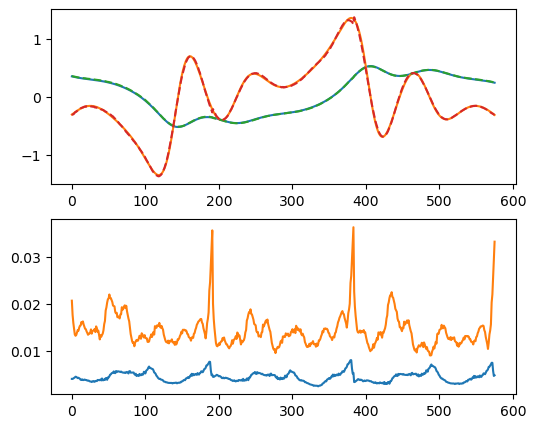

In [15]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        exc = model_output[3]
        exc_u = model_output[4]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

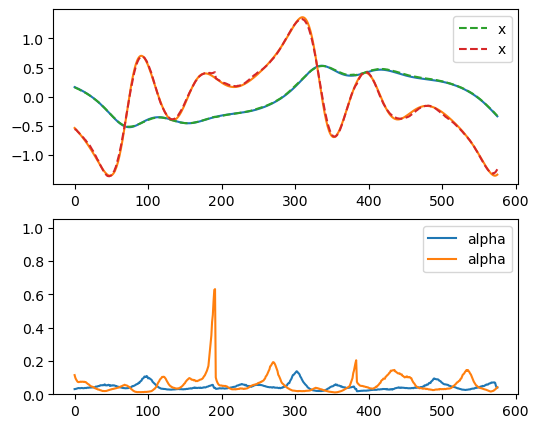

In [16]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        pre = model_output[0]
        alpha = model_output[9]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break